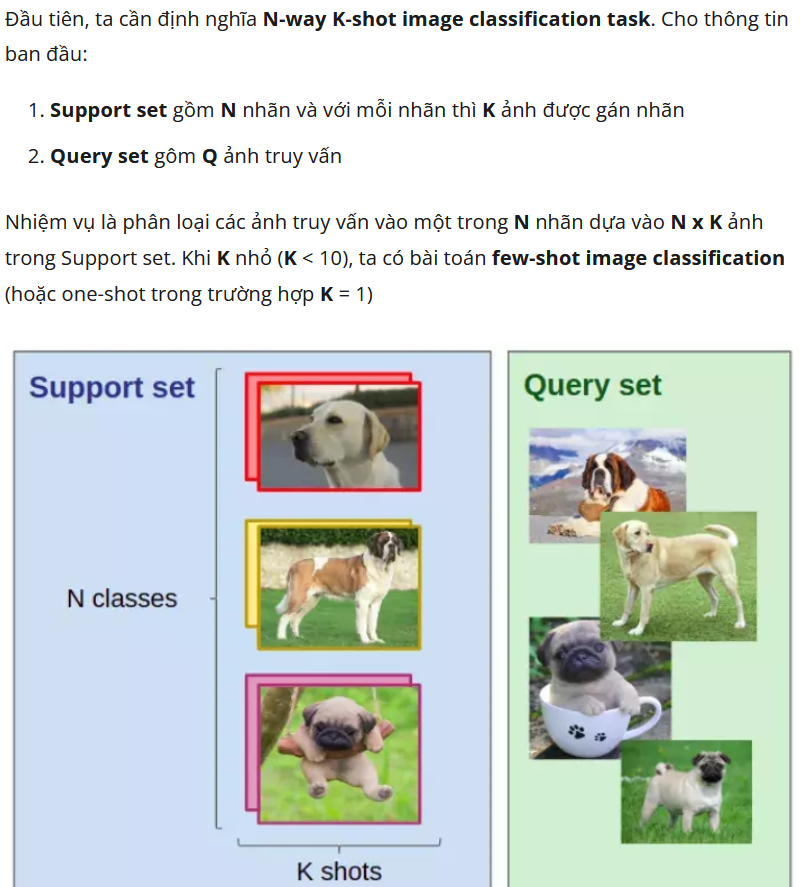

Mục tiêu: dạy máy học như con người, ko cần nhìn thấy hàng trăm con mèo đề nhận mèo, có thể học từ vài ví dụ gần giống để nhận biết hàng trăm con mèo khác nhau 

-> Ý tưởng gốc là Gộp những ví dụ tương đồng lại với nhau (như K-Mean) nhưng ở trong Latent Space vì Latent Representation trừu tượng và có thể đại diện cho nhiều "Class/Biến" khác nhau. 

-> Contrastive Learning khai thác Latent Space để Gộp các Class tương đồng lại với nhau và đẩy các Class khác nhau ra xa. 

**In short:** in Meta-Learning N-way-K-shot **the goals is to learn the Relationship between Data** given this a new Dataset.

## Few-Shot Learning through N-way-K-shot 
### Meta-Training
Example: The model is given 3 episode (3 Task in N-way-K-shot)  from "family" relationship 

**The 3-Ways (Classes/Relationships):** `mother_of`, `father_of`, `brother_of`.

**The Support Set (15 "shots/training example" total):**

+ 5 sentences for `mother_of`: e.g., "Phuong is mother of Thanh."
+ 5 sentences for `father_of`: e.g., "Ha is father of Thanh."
+ 5 sentences for `brother_of`: e.g., "Thanh is brother of Linh."

**The Query Set:** model receive new, *unlabled sentences* like "Linh is sister of Thanh" and its goal is to predict which of the 3 classes it belong to.

**The Training** the model make a prediction, checks if it True/False then update its weights. Its not trying to remember permanently like traditional method but learning the abstract skills of comparing the Query sentence to the 15 Support sentence. 


### Meta-Testing (Few-Shot Test)
Test on a Entirely new class it never seen before. Not Related to the Labels in the Training Dataset. \

**Example** the model given 3 new relation taken from biographical relationships.

**The 3 Ways (New Classes):** SpouseOf, BornIn, EducatedAt. (Notice these are completely different from the corporate relations).

The Support Set (15 shots total):
+ 5 sentences for SpouseOf: e.g., "Marie married Pierre Curie."
+ 5 sentences for BornIn: e.g., "Albert Einstein hails from Ulm."
+ 5 sentences for EducatedAt: e.g., "Alan Turing studied at Cambridge."



**Summary:** The training *goal not learning the label, but learning how to learn*. Like given a entirely new dataset, give the model K-Example then test it across 3 different classes, could the model predicted right. In otherword, *Adaptibility*.

+ Thuật toán thông thường sẽ học cách mapping ảnh → nhãn.
+ Thuật toán meta-learning sẽ học cách mapping support-set → c (.) 


Additional Resource:
+ [LinkedIn Practice](https://www.linkedin.com/pulse/few-shot-learning-everything-you-need-know-cudocompute-czgoc/)

## How Meta-Learning Model solve few-shot classification task ? 
### Metric Learning
Like embedding tokens in NLP, metric learning classify query image by its distant between to the supported Images.
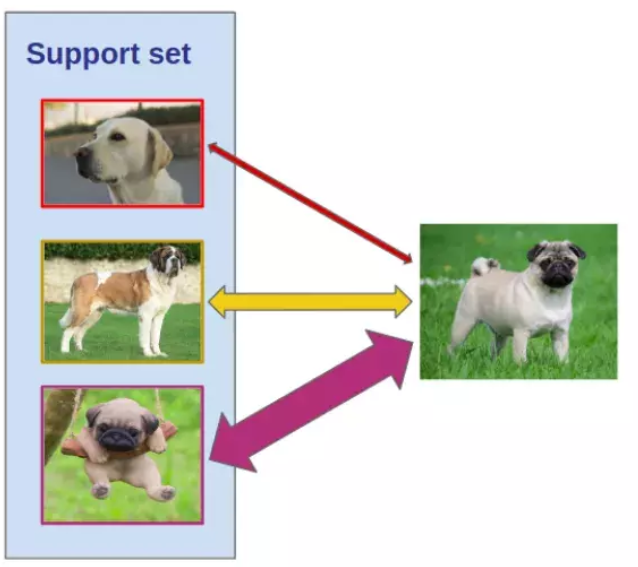

### Metric Learning Algorithm
#### Prototypical Networks
Feature extracted from image, we calc prototype of each class by the average embedding of each images within that class. When prototype was calc, queries get classified using Euclidean distance for prototype.

Note: Multiple embedding methods available as long as its differentiable (in derivatives). 
<img src="prototype.png" width="300">
+ **Prototypes $c_i$** are the "prototypes" or centroids of 3 different class. 
+ **Labeled Training Sample / Support Examples:** is the smaller, colored circles surrounding each prototype/class.
+ **Colored Boundary** is the decision boundaries used to classified the new Query Point.
+ **Classified Query Point ($x$):** the white circle, new/unlabeled data point ("query") the model classified based on the average embedding between each class. 

-> Query $x$ stay within $c_2$ boundary so it classified as $c_2$  

In [11]:
# !pip install easyfsl

In [ ]:
# import random
# from typing import Dict, Iterator, List, Tuple, Union

# import torch
# from torch import Tensor
# from torch.utils.data import Sampler

# from easyfsl.datasets import FewShotDataset

# GENERIC_TYPING_ERROR_MESSAGE = (
#     "Check out the output's type of your dataset's __getitem__() method."
#     "It must be a Tuple[Tensor, int] or Tuple[Tensor, 0-dim Tensor]."
# )


# class TaskSampler(Sampler):
#     """
#     Samples batches in the shape of few-shot classification tasks. At each iteration, it will sample
#     n_way classes, and then sample support and query images from these classes.
#     """

#     def __init__(
#         self,
#         dataset: FewShotDataset,
#         n_way: int,
#         n_shot: int,
#         n_query: int,
#         n_tasks: int,
#     ):
#         """
#         Args:
#             dataset: dataset from which to sample classification tasks. Must have implement get_labels() from
#                 FewShotDataset.
#             n_way: number of classes in one task
#             n_shot: number of support images for each class in one task
#             n_query: number of query images for each class in one task
#             n_tasks: number of tasks to sample
#         """
#         super().__init__()
#         self.n_way = n_way
#         self.n_shot = n_shot
#         self.n_query = n_query
#         self.n_tasks = n_tasks

#         self.items_per_label: Dict[int, List[int]] = {}
#         for item, label in enumerate(dataset.get_labels()):
#             if label in self.items_per_label:
#                 self.items_per_label[label].append(item)
#             else:
#                 self.items_per_label[label] = [item]

#         self._check_dataset_size_fits_sampler_parameters()

#     def __len__(self) -> int:
#         return self.n_tasks

#     def __iter__(self) -> Iterator[List[int]]:
#         """
#         Sample n_way labels uniformly at random,
#         and then sample n_shot + n_query items for each label, also uniformly at random.
#         Yields:
#             a list of indices of length (n_way * (n_shot + n_query))
#         """
#         for _ in range(self.n_tasks):
#             yield torch.cat(
#                 [
#                     torch.tensor(
#                         random.sample(
#                             self.items_per_label[label], self.n_shot + self.n_query
#                         )
#                     )
#                     for label in random.sample(
#                         sorted(self.items_per_label.keys()), self.n_way
#                     )
#                 ]
#             ).tolist()

#     def episodic_collate_fn(
#         self, input_data: List[Tuple[Tensor, Union[Tensor, int]]]
#     ) -> Tuple[Tensor, Tensor, Tensor, Tensor, List[int]]:
#         """
#         Collate function to be used as argument for the collate_fn parameter of episodic
#             data loaders.
#         Args:
#             input_data: each element is a tuple containing:
#                 - an image as a torch Tensor of shape (n_channels, height, width)
#                 - the label of this image as an int or a 0-dim tensor
#         Returns:
#             tuple(Tensor, Tensor, Tensor, Tensor, list[int]): respectively:
#                 - support images of shape (n_way * n_shot, n_channels, height, width),
#                 - their labels of shape (n_way * n_shot),
#                 - query images of shape (n_way * n_query, n_channels, height, width)
#                 - their labels of shape (n_way * n_query),
#                 - the dataset class ids of the class sampled in the episode
#         """
#         input_data_with_int_labels = self._cast_input_data_to_tensor_int_tuple(
#             input_data
#         )
#         true_class_ids = list({x[1] for x in input_data_with_int_labels})
#         all_images = torch.cat([x[0].unsqueeze(0) for x in input_data_with_int_labels])
#         all_images = all_images.reshape(
#             (self.n_way, self.n_shot + self.n_query, *all_images.shape[1:])
#         )
#         all_labels = torch.tensor(
#             [true_class_ids.index(x[1]) for x in input_data_with_int_labels]
#         ).reshape((self.n_way, self.n_shot + self.n_query))
#         support_images = all_images[:, : self.n_shot].reshape(
#             (-1, *all_images.shape[2:])
#         )
#         query_images = all_images[:, self.n_shot :].reshape((-1, *all_images.shape[2:]))
#         support_labels = all_labels[:, : self.n_shot].flatten()
#         query_labels = all_labels[:, self.n_shot :].flatten()
#         return (
#             support_images,
#             support_labels,
#             query_images,
#             query_labels,
#             true_class_ids,
#         )

#     @staticmethod
#     def _cast_input_data_to_tensor_int_tuple(
#         input_data: List[Tuple[Tensor, Union[Tensor, int]]]
#     ) -> List[Tuple[Tensor, int]]:
#         """
#         Check the type of the input for the episodic_collate_fn method, and cast it to the right type if possible.
#         Args:
#             input_data: each element is a tuple containing:
#                 - an image as a torch Tensor of shape (n_channels, height, width)
#                 - the label of this image as an int or a 0-dim tensor
#         Returns:
#             the input data with the labels cast to int
#         Raises:
#             TypeError : Wrong type of input images or labels
#             ValueError: Input label is not a 0-dim tensor
#         """
#         for image, label in input_data:
#             if not isinstance(image, Tensor):
#                 raise TypeError(
#                     f"Illegal type of input instance: {type(image)}. "
#                     + GENERIC_TYPING_ERROR_MESSAGE
#                 )
#             if not isinstance(label, int):
#                 if not isinstance(label, Tensor):
#                     raise TypeError(
#                         f"Illegal type of input label: {type(label)}. "
#                         + GENERIC_TYPING_ERROR_MESSAGE
#                     )
#                 if label.dtype not in {
#                     torch.uint8,
#                     torch.int8,
#                     torch.int16,
#                     torch.int32,
#                     torch.int64,
#                 }:
#                     raise TypeError(
#                         f"Illegal dtype of input label tensor: {label.dtype}. "
#                         + GENERIC_TYPING_ERROR_MESSAGE
#                     )
#                 if label.ndim != 0:
#                     raise ValueError(
#                         f"Illegal shape for input label tensor: {label.shape}. "
#                         + GENERIC_TYPING_ERROR_MESSAGE
#                     )

#         return [(image, int(label)) for (image, label) in input_data]

#     def _check_dataset_size_fits_sampler_parameters(self):
#         """
#         Check that the dataset size is compatible with the sampler parameters
#         """
#         self._check_dataset_has_enough_labels()
#         self._check_dataset_has_enough_items_per_label()

#     def _check_dataset_has_enough_labels(self):
#         if self.n_way > len(self.items_per_label):
#             raise ValueError(
#                 f"The number of labels in the dataset ({len(self.items_per_label)} "
#                 f"must be greater or equal to n_way ({self.n_way})."
#             )

#     def _check_dataset_has_enough_items_per_label(self):
#         number_of_samples_per_label = [
#             len(items_for_label) for items_for_label in self.items_per_label.values()
#         ]
#         minimum_number_of_samples_per_label = min(number_of_samples_per_label)
#         label_with_minimum_number_of_samples = number_of_samples_per_label.index(
#             minimum_number_of_samples_per_label
#         )
#         if self.n_shot + self.n_query > minimum_number_of_samples_per_label:
#             raise ValueError(
#                 f"Label {label_with_minimum_number_of_samples} has only {minimum_number_of_samples_per_label} samples"
#                 f"but all classes must have at least n_shot + n_query ({self.n_shot + self.n_query}) samples."
#             )


In [ ]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import Omniglot
from torchvision.models import resnet18
from tqdm import tqdm
import easyfsl

# from easyfsl.samplers import TaskSampler
from easyfsl.utils import plot_images, sliding_average


Wait, is Few-Shot Learning is like the opposite of Few-Shot Continual Learning ? Because the model is not trying to remember permanently like traditional method but learning the abstract skills of comparing the Query sentence to the 15 Support sentence.

-> **Conflict:** The Goal of Few-Shot Learning (FSL) is Plasticity, while BWT in CL need Stability. To increase BWT, It shouldn't just "adapt" to the new 15 sentences; it must find a way to update its weights so that the new information actually refines its understanding of the previous sentences. 

**Main Problem:**
+ FSL models are prone to overfitting because they have so little data
+ TODO: List out the main challange in Few-Shot Learning / Few-Shot Continual Learning -> See the Conflict. **The goal:** is FSCL a more of a Few-Shot Leraning problem or Relation Extraction Problem.  


-> Compromised Approach: Flat Minima approach is highly promising for Few-Shot Continual Learning (FSCL) bc its provide a "buffer zone" for both old and new task. 

Papers:
+ "SAM" - most popular optimizer for finding flat minima. It has been adapted into variants like SAM-CL and FS-DGPM to specifically balance the multiple objectives found in continual learning.
+ AlterSGD: Uses an alternative gradient descent/ascent strategy to naturally "push" the optimizer toward flatter regions of the loss landscape during each new knowledge session.
**Computational Trade-off:** The main drawback is cost. Seeking flat minima typically requires double the computation (e.g., two forward/backward passes for SAM). Newer frameworks like FLAD are attempting to reduce this overhead by using "noise-only" perturbations.


In [14]:
image_size = 28

train_set = Omniglot(
    root="./data",
    background=True,
    # Apply Data Augmentation for training dataset
    transform=transforms.Compose(
        [
            transforms.Grayscale(num_output_channels=3),
            transforms.RandomResizedCrop(image_size),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
        ]
    ),
    download=True,
)
test_set = Omniglot(
    root="./data",
    background=False,
    # Apply Normalization
    transform=transforms.Compose(
        [
            transforms.Grayscale(num_output_channels=3),
            transforms.Resize([
                int(image_size * 1.15), int(image_size * 1.15)
            ]),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
        ]
    ),
    download=True,
)

In [15]:
#? Prototypical with a Backbone, bc this is a Feature Extractor
class PrototypicalNetwork(nn.Module):
    def __init__(self, backbone: nn.Module):
        super(PrototypicalNetwork, self).__init__()
        self.backbone = backbone

    def forward(
        self,
        support_images: torch.Tensor,
        support_labels: torch.Tensor,
        query_images: torch.Tensor,
    ) -> torch.Tensor:
        """
        Predict query labels in support_labels using support_images
        """

        # Extract the features of support and query images
        #? With Resnet as the input backbone model, we just apply .forward() function to the images to extract it features
        z_support = self.backbone.forward(support_images)
        z_query = self.backbone.forward(query_images)

        # Infer the number of classes from the labels of the support set
        n_way = len(torch.unique(support_labels)) # class to classified

        # Prototype i is the mean of all support features vector with label i
        z_proto = torch.cat(
            [
                z_support[torch.nonzero(support_labels == label)].mean(0)
                for label in range(n_way)
            ]
        )

        # Compute euclidean distant from queries to prototypes
        dists = torch.cdist(z_query, z_proto)
        # print("distant:", dists)

        scores = -dists
        return scores


convolutional_network = resnet18(pretrained=True)
convolutional_network.fc = nn.Flatten() # type: ignore
model = PrototypicalNetwork(convolutional_network).cuda()

### Create the Dataset
We need a dataloader func to move few-shot classification task to model. But normally pytorch dataloader would just add batch of images without consider image's class or image's support set or query. So we need 2 funcs: 
1. a function to distribute image equally in each class.
2. each class need to have a support set and query set.

**For the 1st function**, there are `n_way` Class, then each class will have `k_shot + n_query` images. So total of `n_way * (k_shot + n_query)` images. 

**For the 2nd function** we have custom collate function to replace pytorch built-in collage_fn.

In [ ]:
from typing import Tuple

from easyfsl.datasets import FewShotDataset
from torch import Tensor

N_WAY = 5 # number of classes in a task
K_SHOT = 5 # number of Example/Images per class in support set
N_QUERY = 10 # Number of images per class in the query set
N_EVALUATION_TASK = 100


class OmniglotFewShot(FewShotDataset):
    #? Support Omniglot Class to sastisfied TaskSampler getclass()
    def __init__(self, dataset: Omniglot) -> None:
        super().__init__()
        self.dataset = dataset
        self._labels = [instance[1] for instance in dataset._flat_character_images]

    def __getitem__(self, index: int) -> Tuple[Tensor, int]:
        """Return image and label for few-shot learning."""
        image, _ = self.dataset[index]
        return image, self._labels[index]

    def __len__(self) -> int:
        """Return dataset size."""
        return len(self.dataset)

    def get_labels(self):
        return self._labels

test_set_fewshot = OmniglotFewShot(test_set)

test_sampler = TaskSampler(
    test_set_fewshot,
    n_way=N_WAY,
    n_shot=K_SHOT,
    n_query=N_QUERY,
    n_tasks=N_EVALUATION_TASK,
)

test_loader = DataLoader(
    test_set_fewshot,
    batch_sampler=test_sampler,
    num_workers=0,
    pin_memory=True,
    collate_fn=test_sampler.episodic_collate_fn,
)

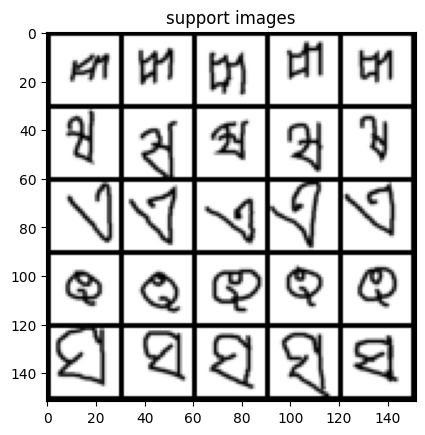

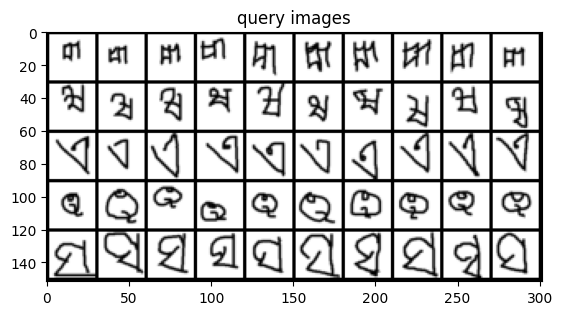

In [17]:
(
    example_support_images,
    example_support_labels,
    example_query_images,
    example_query_labels,
    example_class_ids,
) = next(iter(test_loader))

plot_images(example_support_images, "support images", images_per_row=K_SHOT)
plot_images(example_query_images, "query images", images_per_row=N_QUERY)

In [18]:
model.eval() # enter tranining mode
example_scores = model(
    example_support_images.cuda(),
    example_support_labels.cuda(),
    example_query_images.cuda(),
).detach()

# get max labels score
_, example_predicted_labels = torch.max(example_scores.data, 1)

print("GroundTruth / Predicted")
for i in range(len(example_query_labels)):
    print(
        f"{test_set._characters[example_class_ids[example_query_labels[i]]]} / {test_set._characters[example_class_ids[example_predicted_labels[i]]]}"
    )

GroundTruth / Predicted
Atemayar_Qelisayer\character14 / Atemayar_Qelisayer\character14
Atemayar_Qelisayer\character14 / Atemayar_Qelisayer\character14
Atemayar_Qelisayer\character14 / Atemayar_Qelisayer\character14
Atemayar_Qelisayer\character14 / Atemayar_Qelisayer\character14
Atemayar_Qelisayer\character14 / Atemayar_Qelisayer\character14
Atemayar_Qelisayer\character14 / Atemayar_Qelisayer\character14
Atemayar_Qelisayer\character14 / Tibetan\character29
Atemayar_Qelisayer\character14 / Atemayar_Qelisayer\character14
Atemayar_Qelisayer\character14 / Atemayar_Qelisayer\character14
Atemayar_Qelisayer\character14 / Atemayar_Qelisayer\character14
Tibetan\character29 / Atemayar_Qelisayer\character14
Tibetan\character29 / Tibetan\character29
Tibetan\character29 / Tibetan\character29
Tibetan\character29 / Atemayar_Qelisayer\character14
Tibetan\character29 / Tibetan\character29
Tibetan\character29 / Tibetan\character29
Tibetan\character29 / Atemayar_Qelisayer\character14
Tibetan\character29 

In [ ]:
def evaluate_on_one_task(
    support_images: torch.Tensor,
    support_labels: torch.Tensor,
    query_images: torch.Tensor,
    query_labels: torch.Tensor,
) -> [int, int]:
    """
    Returns the number of correct predictions of query labels, and the total number of predictions.
    """
    return (
        torch.max(
            model(support_images.cuda(), support_labels.cuda(), query_images.cuda())
            .detach()
            .data,
            1,
        )[1]
        == query_labels.cuda()
    ).sum().item(), len(query_labels)


def evaluate(data_loader: DataLoader):
    # We'll count everything and compute the ratio at the end
    total_predictions = 0
    correct_predictions = 0

    # eval mode affects the behaviour of some layers (such as batch normalization or dropout)
    # no_grad() tells torch not to keep in memory the whole computational graph (it's more lightweight this way)
    model.eval()
    with torch.no_grad():
        for episode_index, (
            support_images,
            support_labels,
            query_images,
            query_labels,
            class_ids,
        ) in tqdm(enumerate(data_loader), total=len(data_loader)):

            correct, total = evaluate_on_one_task(
                support_images, support_labels, query_images, query_labels
            )

            total_predictions += total
            correct_predictions += correct

    print(
        f"Model tested on {len(data_loader)} tasks. Accuracy: {(100 * correct_predictions/total_predictions):.2f}%"
    )


evaluate(test_loader)

100%|██████████| 100/100 [00:45<00:00,  2.18it/s]

Model tested on 100 tasks. Accuracy: 85.70%


In [21]:
N_TRAINING_EPISODES = 40000
N_VALIDATION_TASKS = 100

train_set_fewshot = OmniglotFewShot(train_set)
train_sampler = TaskSampler(
    train_set_fewshot, n_way=N_WAY, n_shot=K_SHOT, n_query=N_QUERY, n_tasks=N_TRAINING_EPISODES
)
train_loader = DataLoader(
    train_set,
    batch_sampler=train_sampler,
    num_workers=12,
    pin_memory=True,
    collate_fn=train_sampler.episodic_collate_fn,
)

In [23]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

def fit(
    support_images: torch.Tensor,
    support_labels: torch.Tensor,
    query_images: torch.Tensor,
    query_labels: torch.Tensor,
) -> float:
    optimizer.zero_grad()
    classification_scores = model(
        support_images.cuda(), support_labels.cuda(), query_images.cuda()
    )

    loss = criterion(classification_scores, query_labels.cuda())
    loss.backward()
    optimizer.step()

    return loss.item()

[reference](https://colab.research.google.com/github/sicara/easy-few-shot-learning/blob/master/notebooks/my_first_few_shot_classifier.ipynb#scrollTo=szXN5jgu7p-U)

To train the model, we are just going to iterate over a large number of randomly generated few-shot classification tasks, and let the fit method update our model after each task. This is called episodic training.

This took me 20mn on an RTX 2080 and I promised you that this whole tutorial would take 15mn. So if you don't want to run the training yourself, you can just skip the training and load the model that I trained using the exact same code.

In [ ]:
# Train the model yourself with this cell

log_update_frequency = 10

all_loss = []
model.train()
with tqdm(enumerate(train_loader), total=len(train_loader)) as tqdm_train:
    for episode_index, (
        support_images,
        support_labels,
        query_images,
        query_labels,
        _,
    ) in tqdm_train:
        loss_value = fit(support_images, support_labels, query_images, query_labels)
        all_loss.append(loss_value)

        if episode_index % log_update_frequency == 0:
            tqdm_train.set_postfix(loss=sliding_average(all_loss, log_update_frequency))

In [ ]:
evaluate(test_loader)

|